# Notebook 02 — Event Definition & Detection
Chart style is controlled by one switch (`CHART_STYLE`) in the setup cell below. Figures save to `figures/2_donut/` or `figures/2_bar/` depending on the active style, so both sets can exist on disk at once without overwriting each other.
**Thesis Chapter 6** | **Input:** `data/1_reconstructed.csv` | **Output:** `data/2_events.csv`

---

## What this notebook does

Adds 8 event indicator columns to the reconstructed dataset.
An **event** is a binary or categorical condition at the time of each received packet.
Example: *"Was CO₂ above 700 ppm when this packet arrived?"*

| Event | What it measures |
|-------|-------------------|
| E1 | CO₂ tier |
| E2 | CO₂ rising (first-order delta) |
| E3 | Office hours |
| E4 | PM2.5 tier |
| E5 | Temperature tier |
| E6 | Humidity tier |
| E7 | Spreading factor |
| E8 | ESP tier |
| Burst loss | Descriptive classification of loss-episode length, not a modelled event |

Notebook 03 correlates these events with `PDR_link` (outage intervals excluded).

## 0 · Imports & Load

In [ ]:
import pandas as pd
from pathlib import Path

# TODO - TRY OUT LINE GRAPHS FOR THESIS, AND THE PIE FOR PPT PRESENTATION? TO OPTIMIZE ON SPACE? OR WE CAN PUT SOME CONTENT ON THE RIGHT?

DATA_DIR = Path('../data')
df = pd.read_csv(DATA_DIR / '1_reconstructed.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)
df_link = df[~df['is_outage']].copy()



# ── GUARD: full six-device dataset required ─────────────────────────────────
EXPECTED_DEVICES = ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
EXPECTED_MIN_ROWS = 2_600_000
assert sorted(df['device_id'].unique()) == EXPECTED_DEVICES, (
    f'Subset detected: {sorted(df["device_id"].unique())} — '
    f'regenerate 1_reconstructed.csv from the full dataset before running NB02.'
)
assert len(df) >= EXPECTED_MIN_ROWS, (
    f'Only {len(df):,} rows loaded — expected the full ~2.63M-row campaign.'
)
# ────────────────────────────────────────────────────────────────────────────

print(f'Rows (all)              : {len(df):,}')
print(f'Rows (outage excluded)  : {len(df_link):,}')
print(f'Devices : {sorted(df_link["device_id"].unique())}')
print(f'Campaign: {df_link["time"].min().date()} → {df_link["time"].max().date()}')


In [34]:
print(f"Total rows          : {len(df):,}")
print(f"is_outage == True   : {df['is_outage'].sum():,}")
print(f"is_outage == False  : {(~df['is_outage']).sum():,}")

# Show a sample of outage-flagged rows
print(df[df['is_outage']].head(10)[['device_id', 'time', 'is_outage', 'tx_loss']])

Total rows          : 2,634,930
is_outage == True   : 476
is_outage == False  : 2,634,454
      device_id                             time  is_outage  tx_loss
10885       ED0 2024-10-09 14:19:06.895087+00:00       True        0
10886       ED0 2024-10-09 14:44:19.456632+00:00       True       26
11879       ED0 2024-10-10 11:45:31.212935+00:00       True       79
11880       ED0 2024-10-10 15:09:39.585465+00:00       True      189
13057       ED0 2024-10-11 13:24:53.337752+00:00       True        0
13058       ED0 2024-10-11 13:51:03.046179+00:00       True       36
13091       ED0 2024-10-11 15:36:07.553349+00:00       True       66
14611       ED0 2024-10-13 12:45:52.515311+00:00       True      882
15859       ED0 2024-10-14 14:44:45.790776+00:00       True       10
15860       ED0 2024-10-14 15:12:47.081866+00:00       True       25


In [35]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.patches import Patch

plt.rcParams.update(
    {
        'font.family': 'serif',
        'font.size': 12,
        'axes.titlesize': 13,
        'axes.labelsize': 13,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 11,
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
    }
)
C = {
    'blue': '#0077BB',
    'orange': '#EE7733',
    'green': '#009988',
    'red': '#CC3311',
    'purple': '#AA3377',
    'navy': '#004488',
    'grey': '#BBBBBB',
    'brown': '#882255',
    'teal': '#44AA99',
    'yellow': '#DDCC77',
}
DEVICE_COLORS = [C['blue'], C['orange'], C['green'], C['red'], C['purple'], C['navy']]
TOA_MS = {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6, 11: 987.1, 12: 1810.4}

# ── Chart style switch ───────────────────────────────────────────────────
# 'donut' -> legend-only donut, no leader lines, matches the thesis figures
# 'bar'   -> single horizontal stacked bar, more compact for small multiples
# Figures for each style land in their own folder so switching this and
# re-running does not overwrite the other set.

CHART_STYLE = 'bar'  # 'donut' | 'bar'

# Figure naming convention:  <thesis chapter>_<notebook>_<letter>_<topic>
#   e.g. 04_02_a_co2_tier_distribution  ->  chapter 4, notebook 02, figure a
FIG_DIR = Path(f'../figures/2_{CHART_STYLE}')
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    # fig.savefig(FIG_DIR / f'{name}.pdf')
    fig.savefig(FIG_DIR / f'{name}.png')
    print(f'  Saved: {FIG_DIR}/{name}.png')
    plt.show()


def _pct(v):
    """Percentage label with precision that adapts to magnitude."""
    if v == 0:
        return '0%'
    if v < 0.1:
        return f'{v:.3f}%'
    if v < 1:
        return f'{v:.2f}%'
    return f'{v:.1f}%'


def _text_on(color):
    """Black or white inline text, whichever reads better on the given fill."""
    r, g, b = mcolors.to_rgb(color)
    return 'black' if (0.299 * r + 0.587 * g + 0.114 * b) > 0.6 else 'white'


def donut_compact(values, labels, colors, figsize=(5.6, 2.9), width=0.42):
    """Compact donut. Every share is carried in the legend rather than on the
    chart, so no leader lines are needed and tiny categories stay readable."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.pie(
        values,
        colors=colors,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=width, edgecolor='white', linewidth=1.2),
    )
    ax.set_aspect('equal')
    ax.axis('off')

    handles = [Patch(facecolor=c, edgecolor='white', linewidth=0.8) for c in colors]
    leg = [f'{l}  ({_pct(v)})' for l, v in zip(labels, values)]
    ax.legend(
        handles, leg,
        loc='center left', bbox_to_anchor=(0.95, 0.5),
        frameon=False, fontsize=14, handlelength=1.0, handleheight=1.0,
        labelspacing=0.55, borderpad=0.0,
        ncol=2 if len(values) > 4 else 1, columnspacing=1.0,
    )
    fig.tight_layout()
    return fig, ax


def stacked_bar_compact(values, labels, colors, figsize=(14, 3), inline_min=7.0):
    """Single horizontal stacked bar spanning the full figure width edge to
    edge. Segments at or above inline_min percent carry an inline label, and
    every category is listed with its share in the legend below the bar.
    This is the one function every event figure calls, so its settings are
    the single source of truth for all eight charts. If you change a value
    here, re-run every figure cell (Run All) so the outputs stay consistent
    across events -- otherwise older PNGs on disk keep the previous look
    until their own cell is re-executed."""
    fig, ax = plt.subplots(figsize=figsize)
    # Explicit position rather than tight_layout: matplotlib's default axes
    # rect leaves ~12% margin on each side even with axis('off'), which
    # tight_layout does not fully remove. Setting the rect directly makes the
    # bar span the whole canvas horizontally rather than sitting inset.
    ax.set_position([0.0, 0.32, 1.0, 0.40])

    left = 0.0
    for v, c in zip(values, colors):
        # height is deliberately larger than the y-limits below, so the bar
        # is clipped to fill the full visible vertical band edge to edge
        # rather than sitting as a thin strip with padding above and below.
        ax.barh(0, v, left=left, color=c, edgecolor='white', height=1.5, linewidth=1.0)
        if v >= inline_min:
            ax.text(
                left + v / 2, 0, _pct(v),
                ha='center', va='center',
                color=_text_on(c), fontweight='bold', fontsize=25,
            )
        left += v

    ax.set_xlim(0, 100)
    ax.set_ylim(-0.5, 0.45)
    ax.axis('off')

    handles = [Patch(facecolor=c, edgecolor='white', linewidth=0.8) for c in colors]
    leg = [f'{l}  ({_pct(v)})' for l, v in zip(labels, values)]
    ax.legend(
        handles, leg,
        loc='upper center', bbox_to_anchor=(0.5, -0.1),
        frameon=False, fontsize=20, ncol=min(len(values), 3),
        handlelength=1.0, handleheight=1.0, columnspacing=1.6, borderpad=0.0,
    )
    return fig, ax


def event_chart(values, labels, colors):
    """Dispatches to the active CHART_STYLE. Every figure cell below calls
    this one function, so CHART_STYLE is the single place that decides which
    style renders across the whole notebook."""
    if CHART_STYLE == 'donut':
        return donut_compact(values, labels, colors)
    if CHART_STYLE == 'bar':
        return stacked_bar_compact(values, labels, colors)
    raise ValueError(f"CHART_STYLE must be 'donut' or 'bar', got {CHART_STYLE!r}")


print(f'Figure settings ready. CHART_STYLE = {CHART_STYLE!r}  ->  saving to {FIG_DIR}/')


Figure settings ready. CHART_STYLE = 'donut'  ->  saving to ..\figures\2_donut/


## 1 · CO₂ Tier  *(§6.1)*

CO₂ rises linearly with the number of people present — human metabolism produces ~200 ml CO₂/min at rest.  
Outdoor ambient is ~420 ppm. Weekday mean in this building is ~576 ppm vs ~457 ppm on weekends.

| Event | Definition |
|-------|-----------|
| E1 | CO₂ tier: background (<500) / moderate (500–700) / high (>700 ppm) |

In [36]:
# E1: CO2 tier — 500 ppm = outdoor ambient ceiling, 700 ppm = moderate occupancy onset
df['e1_co2_tier'] = pd.cut(
    df['co2'], bins=[0, 500, 700, 10_000], labels=['background', 'moderate', 'high']
)

print('CO2 tier distribution (E1):')
print(
    df['e1_co2_tier']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .astype(str)
    .add('%')
    .to_string()
)
print(
    f'\nCO2 mean overall         : {df["co2"].mean():.0f} ppm  |  std: {df["co2"].std():.0f} ppm'
)

CO2 tier distribution (E1):
e1_co2_tier
background    63.4%
moderate      28.2%
high           8.4%

CO2 mean overall         : 516 ppm  |  std: 117 ppm


  Saved: ..\figures\2_donut/04_02_a_co2_tier_distribution.png


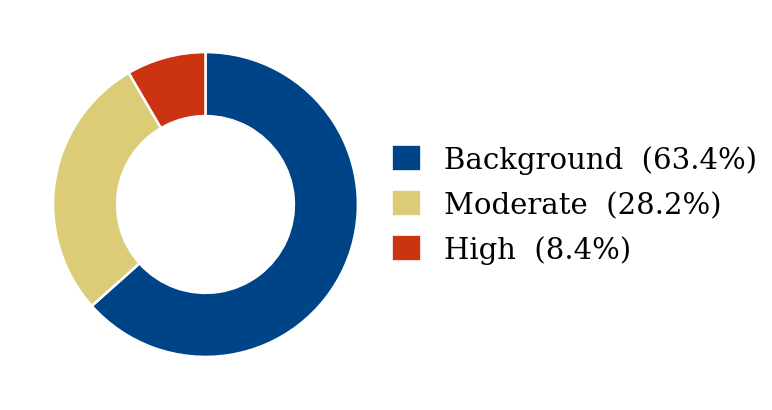

In [37]:
# Fig 04-02-a — CO2 Tier Distribution (E1)
tiers  = ['background', 'moderate', 'high']
vals   = [float(df['e1_co2_tier'].astype(str).eq(t).mean() * 100) for t in tiers]
labs   = ['Background', 'Moderate', 'High']
colors = [C['navy'], C['yellow'], C['red']]

fig, ax = event_chart(vals, labs, colors)   # renders as CHART_STYLE
save_fig(fig, '04_02_a_co2_tier_distribution')


## 2 · CO₂ Rising  *(§6.2)*

| Event | Definition |
|-------|-----------|
| E2 | CO₂ rising: delta > 15 ppm per 60s |

In [38]:
# E2: CO2 rising — delta > 15 ppm/60s
# todo CHECK FOR ABSOLUTE VALUES; RENAME TO DELTA CO2, OR STH THAT MAKES SENSE
# 15 ppm chosen to exceed Sensirion SCD41 sensor noise (~±10 ppm)
df['e2_co2_rising'] = (df.groupby('device_id')['co2'].diff() > 15).astype(int)

print(
    f'CO2 rising intervals (E2): {df["e2_co2_rising"].sum():,}  ({df["e2_co2_rising"].mean() * 100:.1f}% of all intervals)'
)

CO2 rising intervals (E2): 6,430  (0.2% of all intervals)


  Saved: ..\figures\2_donut/04_02_b_co2_rising_frequency.png


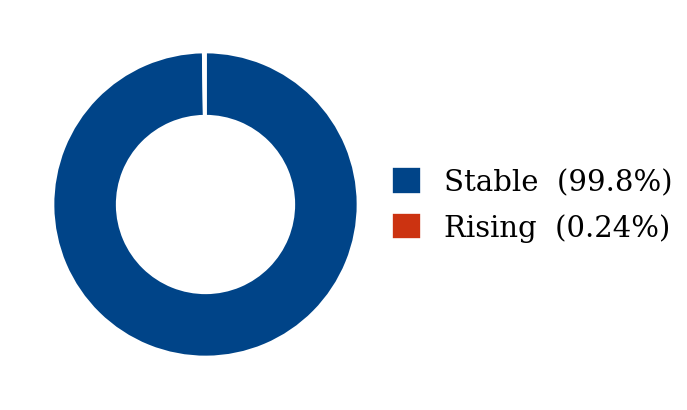

In [39]:
# Fig 04-02-b — CO2 Rising Frequency (E2)
rising = float(df['e2_co2_rising'].mean() * 100)
vals   = [100 - rising, rising]
labs   = ['Stable', 'Rising']
colors = [C['navy'], C['red']]

fig, ax = event_chart(vals, labs, colors)   # renders as CHART_STYLE
save_fig(fig, '04_02_b_co2_rising_frequency')


## 3 · Office Hours  *(§6.3)*

Converted to `Europe/Berlin` local time — handles both DST transitions  
(October 2024 and March 2025) automatically.

| Event | Definition |
|-------|-----------|
| E3 | Office hours — weekday AND 08:00–17:59 |

In [40]:
# local time — required for correct hour/weekday extraction across DST boundaries
local = df['time'].dt.tz_convert('Europe/Berlin')
df['hour'] = local.dt.hour
df['dayofweek'] = local.dt.dayofweek  # 0=Monday, 6=Sunday

# E3: office hours — weekday AND 08:00–17:59
df['is_weekday'] = (df['dayofweek'] < 5).astype(int)

df['e3_office_hours'] = ((df['is_weekday'] == 1) & df['hour'].between(8, 17)).astype(int)

print(f'Office hours (E3): {df["e3_office_hours"].mean() * 100:.1f}%')

Office hours (E3): 29.2%


  Saved: ..\figures\2_donut/04_02_c_temporal_distributions.png


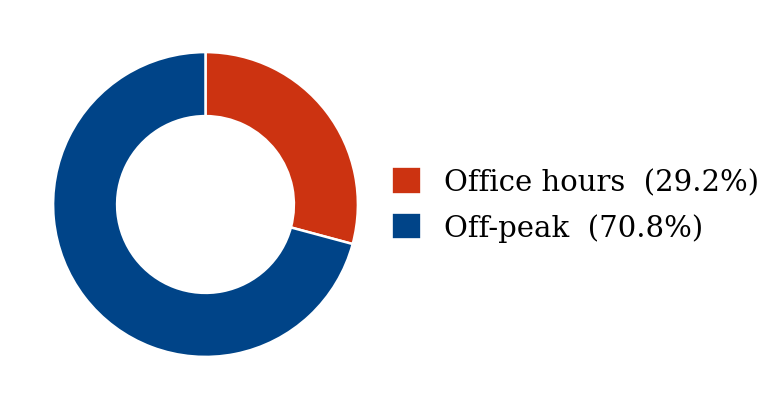

In [41]:
# Fig 04-02-c — Temporal Event Distribution (E3)
oh   = float(df['e3_office_hours'].mean() * 100)
vals = [oh, 100 - oh]
labs   = ['Office hours', 'Off-peak']
colors = [C['red'], C['navy']]

fig, ax = event_chart(vals, labs, colors)   # renders as CHART_STYLE
save_fig(fig, '04_02_c_temporal_distributions')


## 4 · PM2.5 Tier  *(§6.4)*

PM2.5 correlates with human activity bursts — cleaning, printing, cooking —  
rather than directly attenuating 868 MHz signals.

| Event | Definition |
|-------|-----------|
| E4    | PM2.5 absolute tier: clean (≤10) / moderate (10–25) / elevated (>25 µg/m³), WHO Global Air Quality Guidelines |

In [42]:
# E4: absolute WHO-aligned PM2.5 tier
df['e4_pm25_tier'] = pd.cut(
    df['pm25'], bins=[-0.01, 5, 15, 10_000], labels=['clean', 'moderate', 'elevated']
)

print('PM2.5 tier distribution (E4):')
print(df['e4_pm25_tier'].value_counts(normalize=True).mul(100).round(1).to_string())

PM2.5 tier distribution (E4):
e4_pm25_tier
clean       91.6
moderate     8.2
elevated     0.3


  Saved: ..\figures\2_donut/04_02_d_pm25_events.png


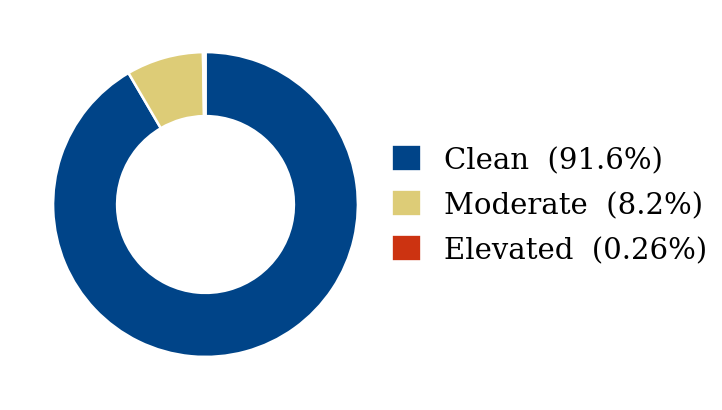

In [43]:
# Fig 04-02-d — PM2.5 Event Distribution (E4)
tiers = ['clean', 'moderate', 'elevated']
vals  = [float(df['e4_pm25_tier'].astype(str).eq(t).mean() * 100) for t in tiers]
labs   = ['Clean', 'Moderate', 'Elevated']
colors = [C['navy'], C['yellow'], C['red']]
# colors = [C['green'], C['orange'], C['red']]

fig, ax = event_chart(vals, labs, colors)   # renders as CHART_STYLE
save_fig(fig, '04_02_d_pm25_events')


## 5 · Temperature Tier  *(§6.5)*

| Event | Definition |
|-------|-----------|
| E5    | Temperature tier: cool (≤21.9°C) / moderate (21.9–25.3°C) / warm (>25.3°C) — tertiles of the deployment distribution |

In [44]:
# E5: temperature tier — tertiles of the deployment distribution (locked thresholds)
df['e5_temp_tier'] = pd.cut(
    df['temperature'], bins=[-100, 21.9, 25.3, 100], labels=['cool', 'moderate', 'warm']
)

print(f'Temperature range: {df["temperature"].min():.1f} – {df["temperature"].max():.1f} °C')
print(f'E5 tertile thresholds: 21.9°C / 25.3°C')
print('E5 temperature tier distribution:')
print(
    df['e5_temp_tier']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .astype(str)
    .add('%')
    .to_string()
)

Temperature range: 13.7 – 46.3 °C
E5 tertile thresholds: 21.9°C / 25.3°C
E5 temperature tier distribution:
e5_temp_tier
moderate    33.7%
cool        33.3%
warm        33.1%


  Saved: ..\figures\2_donut/04_02_e_temperature_distribution.png


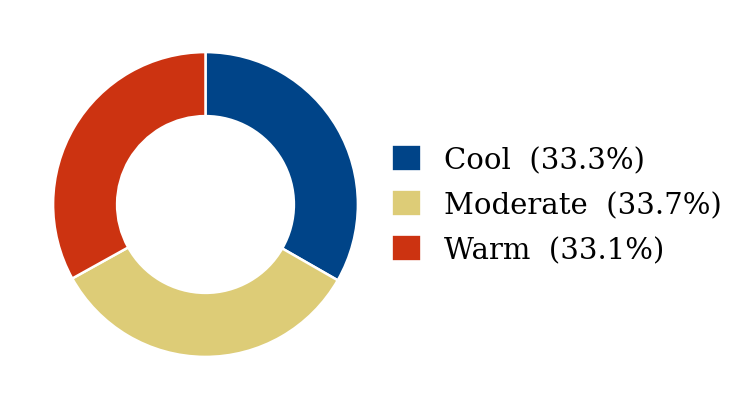

In [45]:
# Fig 04-02-e — Temperature Tier Distribution (E5)
tiers = ['cool', 'moderate', 'warm']
vals  = [float(df['e5_temp_tier'].astype(str).eq(t).mean() * 100) for t in tiers]
labs   = ['Cool', 'Moderate', 'Warm']
colors = [C['navy'], C['yellow'], C['red']]

fig, ax = event_chart(vals, labs, colors)   # renders as CHART_STYLE
save_fig(fig, '04_02_e_temperature_distribution')


## 6 · Humidity Tier  *(§6.6)*

| Event | Definition                                                                       |
|-------|----------------------------------------------------------------------------------|
| E6    | Humidity tier: dry (<30%) / normal (30–60%) / humid (>60%) — WHO indoor dampness |

In [46]:
# E6: humidity tier — WHO indoor-dampness guidance boundaries (thesis §3.4.6)
df['e6_humidity_tier'] = pd.cut(
    df['humidity'], bins=[0, 30, 60, 100], labels=['dry', 'normal', 'humid']
)
print(f'Humidity range   : {df["humidity"].min():.1f} – {df["humidity"].max():.1f} %')
print(df['e6_humidity_tier'].value_counts(normalize=True).mul(100).round(2).to_string())

# # E6: humidity tier — ASHRAE 55 comfort boundaries
# df['e6_humidity_tier'] = pd.cut(
#     df['humidity'], bins=[0, 30, 60, 100], labels=['dry', 'normal', 'humid']
# )
#
# print(f'Humidity range   : {df["humidity"].min():.1f} – {df["humidity"].max():.1f} %')

Humidity range   : 14.0 – 62.8 %
e6_humidity_tier
normal    85.26
dry       14.71
humid      0.03


  Saved: ..\figures\2_donut/04_02_f_humidity_distribution.png


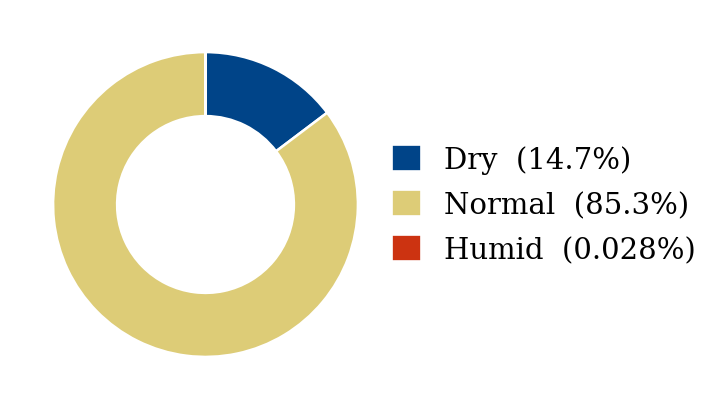

In [47]:
# Fig 04-02-f — Humidity Tier Distribution (E6)
tiers = ['dry', 'normal', 'humid']
vals  = [float(df['e6_humidity_tier'].astype(str).eq(t).mean() * 100) for t in tiers]
labs   = ['Dry', 'Normal', 'Humid']
colors = [C['navy'], C['yellow'], C['red']]

fig, ax = event_chart(vals, labs, colors)   # renders as CHART_STYLE
save_fig(fig, '04_02_f_humidity_distribution')


## 7 · Spreading Factor Event  *(§6.7)*

SF directly controls Time-on-Air (ToA) — the duration a packet occupies the channel.  
Under LoRaWAN's ALOHA protocol, longer ToA = wider collision window = higher loss probability.

ADR was disabled. SF rotated in a fixed cycle: SF12→SF11→SF10→SF9→SF8→SF7.  
SF11/SF12 blocks are truncated to 4 packets by duty cycle enforcement (§5.2.1).

| SF | ToA (ms) | Collision window vs SF7 |
|----|---------|------------------------|
| 7 | 71.9 | baseline |
| 8 | 133.6 | 1.9× |
| 9 | 246.8 | 3.4× |
| 10 | 452.6 | 6.3× |
| 11 | 987.1 | 13.7× |
| 12 | 1810.4 | 25.2× |

| Event | Definition |
|-------|-----------|
| E7   | SF categorical: 7 / 8 / 9 / 10 / 11 / 12 |

In [48]:
# E7: individual SF value
TOA_MS = {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6, 11: 987.1, 12: 1810.4}
df['e7_sf'] = df['SF'].astype(int)

print('SF Distribution (E7):')
for sf in [7, 8, 9, 10, 11, 12]:
    n = (df['e7_sf'] == sf).sum()
    print(f'  SF{sf} (ToA={TOA_MS[sf]:7.1f}ms): {n:,} ({n / len(df) * 100:.1f}%)')

SF Distribution (E7):
  SF7 (ToA=   71.9ms): 537,023 (20.4%)
  SF8 (ToA=  133.6ms): 534,546 (20.3%)
  SF9 (ToA=  246.8ms): 518,734 (19.7%)
  SF10 (ToA=  452.6ms): 500,838 (19.0%)
  SF11 (ToA=  987.1ms): 269,220 (10.2%)
  SF12 (ToA= 1810.4ms): 274,569 (10.4%)


  Saved: ..\figures\2_donut/04_02_g_sf_distribution.png


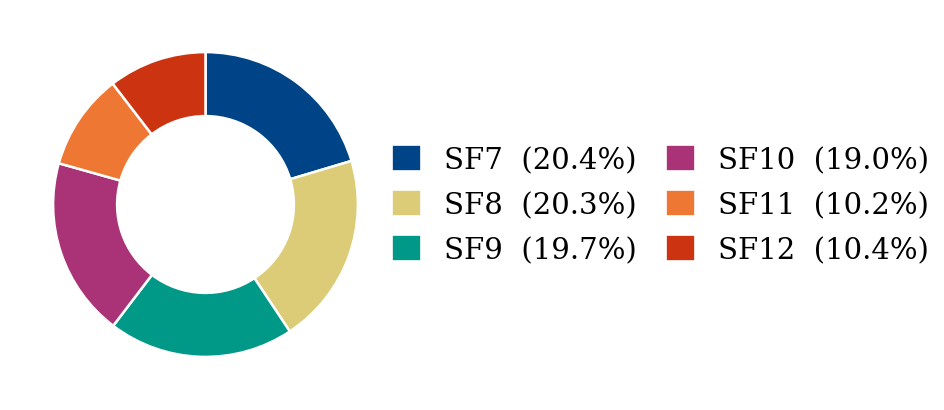

In [49]:
# Fig 04-02-g — Spreading-Factor Distribution (E7)
sfs  = [7, 8, 9, 10, 11, 12]
vals = [float(df['e7_sf'].eq(sf).mean() * 100) for sf in sfs]
labs   = [f'SF{sf}' for sf in sfs]
colors = [C['navy'], C['yellow'], C['green'], C['purple'], C['orange'], C['red']]

fig, ax = event_chart(vals, labs, colors)   # renders as CHART_STYLE
save_fig(fig, '04_02_g_sf_distribution')


## 8 · ESP Event  *(§6.8)*

ESP (effective signal power) is only available for received packets — never for lost ones.  
E8 uses the ESP of the packet received immediately before the loss interval  
as a proxy for channel state at the time of loss.

| Event | Definition |
|-------|-----------|
| E8   | ESP tier: poor / moderate / strong (threshold source under review — see notebook 03) |

In [50]:
# E8: ESP tier — collapsed to 3 analytical tiers from ThingPark 6-band classification
# poor    = critical + very_weak  (below -120 dBm)
# moderate = weak + fair          (-120 to -100 dBm)
# strong  = good + excellent      (above -100 dBm)
df['e8_esp_tier'] = pd.cut(
    df['esp'], bins=[-300, -120, -100, 0], labels=['poor', 'moderate', 'strong']
)

print("ESP tier distribution (E8) — 3 analytical tiers:")
print(
    df['e8_esp_tier']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reindex(['poor', 'moderate', 'strong'])
    .to_string()
)
print(f"\nRaw counts:")
print(df['e8_esp_tier'].value_counts().reindex(['poor', 'moderate', 'strong']).to_string())

ESP tier distribution (E8) — 3 analytical tiers:
e8_esp_tier
poor         8.73
moderate     4.41
strong      86.86

Raw counts:
e8_esp_tier
poor         230117
moderate     116207
strong      2288606


  Saved: ..\figures\2_donut/04_02_h_signal_quality_distribution.png


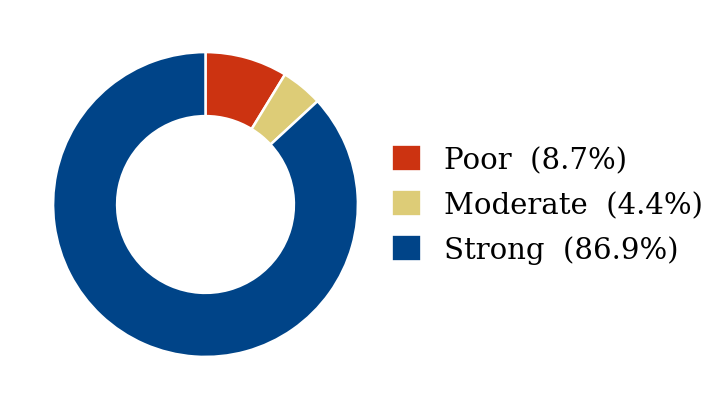

In [51]:
# Fig 04-02-h — ESP Tier Distribution (E8)
tiers = ['poor', 'moderate', 'strong']
vals  = [float(df['e8_esp_tier'].astype(str).eq(t).mean() * 100) for t in tiers]
labs   = ['Poor', 'Moderate', 'Strong']
colors = [C['red'], C['yellow'], C['navy']]

fig, ax = event_chart(vals, labs, colors)   # renders as CHART_STYLE
save_fig(fig, '04_02_h_signal_quality_distribution')


## 10 · Event Reference Table  *(Table 6.1)*

Complete list of all 8 events — copy to Table 6.1 in the thesis.

In [52]:
# Event Definitions — 8 events E1–E8
event_definitions = [
    ('E1', 'e1_co2_tier', 'CO2 concentration tier (background/moderate/high)'),
    ('E2', 'e2_co2_rising', 'CO2 rising > 15ppm/60s'),
    ('E3', 'e3_office_hours', 'Office hours — weekday AND 08:00–17:59'),
    ('E4', 'e4_pm25_tier', 'PM2.5 absolute tier (clean/moderate/elevated)'),
    ('E5', 'e5_temp_tier', 'Temperature tertile tier (cool/moderate/warm)'),
    ('E6', 'e6_humidity_tier', 'Relative humidity tier (dry/normal/humid)'),
    ('E7', 'e7_sf', 'Spreading factor (SF7–SF12)'),
    (
        'E8',
        'e8_esp_tier',
        'ESP tier: poor (<-120 dBm) / moderate (-120 to -100 dBm) / strong (>-100 dBm)',
    ),
]

print(f"{'ID':<5} {'Column':<22} {'Definition'}")
print('-' * 80)
for row in event_definitions:
    print(f'{row[0]:<5} {row[1]:<22} {row[2]}')
print(f'\nTotal: {len(event_definitions)} events (E1–E8)')

ID    Column                 Definition
--------------------------------------------------------------------------------
E1    e1_co2_tier            CO2 concentration tier (background/moderate/high)
E2    e2_co2_rising          CO2 rising > 15ppm/60s
E3    e3_office_hours        Office hours — weekday AND 08:00–17:59
E4    e4_pm25_tier           PM2.5 absolute tier (clean/moderate/elevated)
E5    e5_temp_tier           Temperature tertile tier (cool/moderate/warm)
E6    e6_humidity_tier       Relative humidity tier (dry/normal/humid)
E7    e7_sf                  Spreading factor (SF7–SF12)
E8    e8_esp_tier            ESP tier: poor (<-120 dBm) / moderate (-120 to -100 dBm) / strong (>-100 dBm)

Total: 8 events (E1–E8)


## 11 · All Events Overview  *(Fig 4.15)*

  Saved: ..\figures\2_donut/04_02_i_all_events_overview.png


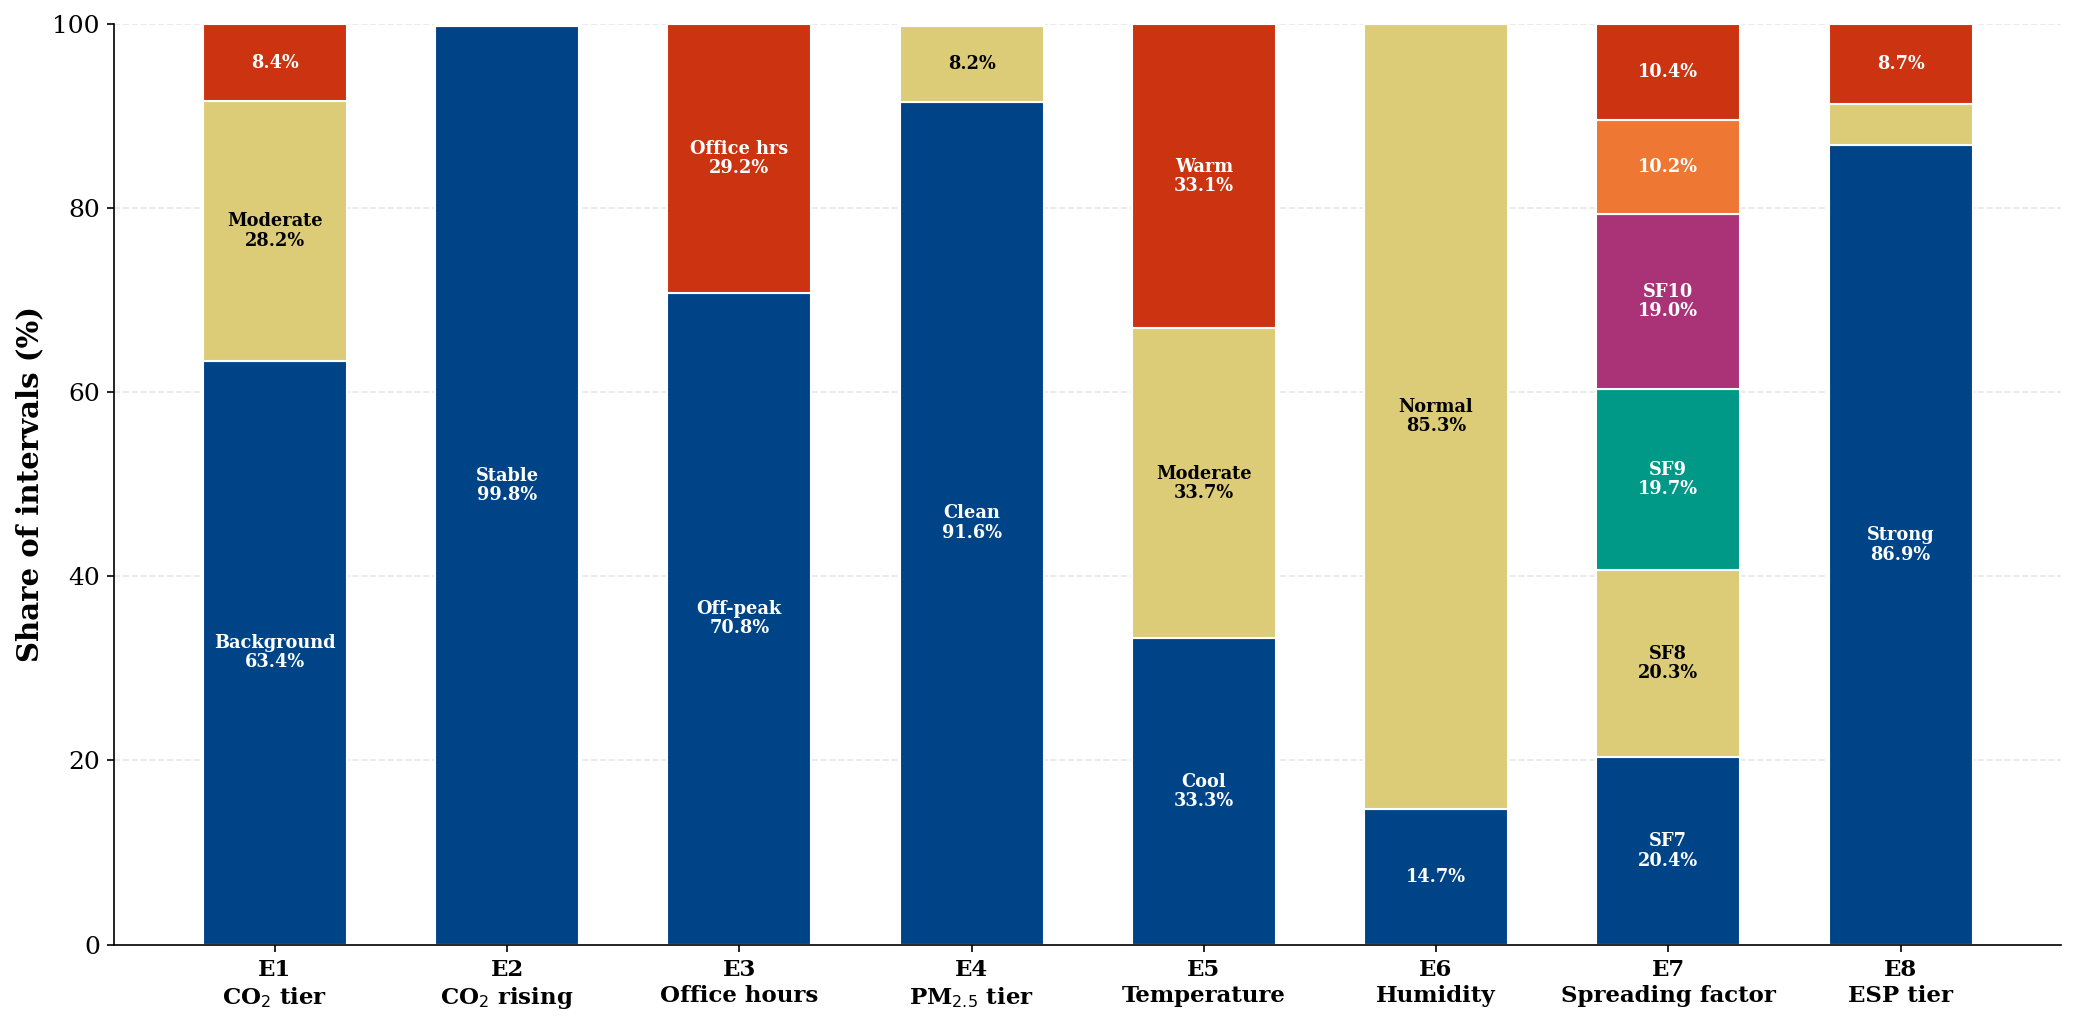

In [53]:
# Fig 04-02-i — All Events Overview (E1-E8)
# One 100%-stacked column per event, sharing the y-axis (0-100%) so every
# taxonomy's tier split is visible on a single figure. Colors match the
# individual event figures above. Segments carry an inline label only when
# they are tall enough to hold text without crowding neighbors; the smallest
# slices (e.g. E2 rising, E6 humid) are still visible as slivers but are
# left unlabeled here -- see Figures 04-02-a to 04-02-h for their exact
# values and full legends.

events_overview = [
    dict(code='E1', name='CO$_2$ tier',
         vals=[float(df['e1_co2_tier'].astype(str).eq(t).mean() * 100)
               for t in ['background', 'moderate', 'high']],
         labs=['Background', 'Moderate', 'High'],
         colors=[C['navy'], C['yellow'], C['red']]),
    dict(code='E2', name='CO$_2$ rising',
         vals=[100 - float(df['e2_co2_rising'].mean() * 100),
               float(df['e2_co2_rising'].mean() * 100)],
         labs=['Stable', 'Rising'],
         colors=[C['navy'], C['red']]),
    dict(code='E3', name='Office hours',
         vals=[100 - float(df['e3_office_hours'].mean() * 100),
               float(df['e3_office_hours'].mean() * 100)],
         labs=['Off-peak', 'Office hrs'],
         colors=[C['navy'], C['red']]),
    dict(code='E4', name='PM$_{2.5}$ tier',
         vals=[float(df['e4_pm25_tier'].astype(str).eq(t).mean() * 100)
               for t in ['clean', 'moderate', 'elevated']],
         labs=['Clean', 'Moderate', 'Elevated'],
         colors=[C['navy'], C['yellow'], C['red']]),
    dict(code='E5', name='Temperature',
         vals=[float(df['e5_temp_tier'].astype(str).eq(t).mean() * 100)
               for t in ['cool', 'moderate', 'warm']],
         labs=['Cool', 'Moderate', 'Warm'],
         colors=[C['navy'], C['yellow'], C['red']]),
    dict(code='E6', name='Humidity',
         vals=[float(df['e6_humidity_tier'].astype(str).eq(t).mean() * 100)
               for t in ['dry', 'normal', 'humid']],
         labs=['Dry', 'Normal', 'Humid'],
         colors=[C['navy'], C['yellow'], C['red']]),
    dict(code='E7', name='Spreading factor',
         vals=[float(df['e7_sf'].eq(sf).mean() * 100) for sf in [7, 8, 9, 10, 11, 12]],
         labs=[f'SF{sf}' for sf in [7, 8, 9, 10, 11, 12]],
         colors=[ C['navy'], C['yellow'], C['green'], C['purple'], C['orange'], C['red']]),

    dict(code='E8', name='ESP tier',
         vals=[float(df['e8_esp_tier'].astype(str).eq(t).mean() * 100)
               for t in ['strong', 'moderate', 'poor']],
         labs=['Strong', 'Moderate', 'Poor'],
         colors=[C['navy'], C['yellow'], C['red']]),
]

fig, ax = plt.subplots(figsize=(14, 7))
xs = np.arange(len(events_overview))
width = 0.62

for x, ev in zip(xs, events_overview):
    bottom = 0.0
    for v, lab, c in zip(ev['vals'], ev['labs'], ev['colors']):
        ax.bar(x, v, width, bottom=bottom, color=c, edgecolor='white', linewidth=1.0)
        if v >= 15:
            ax.text(x, bottom + v / 2, f'{lab}\n{_pct(v)}', ha='center', va='center',
                    color=_text_on(c), fontsize=8.5, fontweight='bold', linespacing=1.1)
        elif v >= 6:
            ax.text(x, bottom + v / 2, _pct(v), ha='center', va='center',
                    color=_text_on(c), fontsize=8.5, fontweight='bold')
        bottom += v

ax.set_xticks(xs)
ax.set_xticklabels([f"{ev['code']}\n{ev['name']}" for ev in events_overview],
                   fontsize=11, fontweight='bold')
ax.set_ylabel('Share of intervals (%)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 20))
ax.tick_params(axis='y', labelsize=12)
ax.set_axisbelow(True)

fig.tight_layout()
save_fig(fig, '04_02_i_all_events_overview')


## Save  *(2_events.csv)*

| Event | Column |
|-------|--------|
| E1 | `e1_co2_tier` |
| E2 | `e2_co2_rising` |
| E3 | `e3_office_hours` |
| E4 | `e4_pm25_tier` |
| E5 | `e5_temp_tier` |
| E6 | `e6_humidity_tier` |
| E7 | `e7_sf` |
| E8 | `e8_esp_tier` |
| Burst loss (descriptive) | `loss_type` |

In [54]:
original_cols = [
    c
    for c in df.columns
    if not (c.startswith('e') and '_' in c)
       and c not in ['hour', 'dayofweek', 'month', 'exp_pl']
]

event_cols_ordered = [
    'e1_co2_tier',
    'e2_co2_rising',
    'e3_office_hours',
    'e4_pm25_tier',
    'e5_temp_tier',
    'e6_humidity_tier',
    'e7_sf',
    'e8_esp_tier',
]

df = df[
    [c for c in original_cols if c in df.columns]
    + [c for c in event_cols_ordered if c in df.columns]
    ]
df.to_csv(DATA_DIR / '2_events.csv', index=False)

print(f'Saved  : {DATA_DIR / "2_events.csv"}')
print(f'Rows   : {len(df):,}')
print(f'Columns: {len(df.columns)} total | 8 events (E1–E8) + loss_type + E9 (experimental)')

Saved  : ..\data\2_events.csv
Rows   : 2,634,930
Columns: 35 total | 8 events (E1–E8) + loss_type + E9 (experimental)
